## Step 1: Load the mesh

In [2]:
#from geolab.data.components.coordinate_data.mesh import ERA5MultiData
import xarray as xr

In [3]:
root_dir = r"C:\Users\micke\Downloads\dfda178b22d3772b9b9b0118dba68a02.nc"
test = xr.open_dataset(root_dir)
test

<xarray.Dataset>
Dimensions:         (valid_time: 24, pressure_level: 17, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 2022-09-28 ... 2022-09-28T23:...
  * pressure_level  (pressure_level) float64 850.0 825.0 800.0 ... 225.0 200.0
  * latitude        (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude       (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    number          int64 ...
    expver          (valid_time) object ...
    z               (valid_time, pressure_level, latitude, longitude) float32 ...
    t               (valid_time, pressure_level, latitude, longitude) float32 ...
    u               (valid_time, pressure_level, latitude, longitude) float32 ...
    v               (valid_time, pressure_level, latitude, longitude) float32 ...
    w               (valid_time, pressure_level, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-19T17:48 GRIB to CDM+CF via cfgrib-0.9.1...

In [61]:
test.dims

Frozen({'valid_time': 24, 'pressure_level': 17, 'latitude': 721, 'longitude': 1440})

In [77]:
for i in test.coords:
    x = (i,test.coords[i].data ,len(test.coords[i].data), str(test.coords[i].values.dtype))
    print(x)
    break

('valid_time', array(['2022-09-28T00:00:00.000000000', '2022-09-28T01:00:00.000000000',
       '2022-09-28T02:00:00.000000000', '2022-09-28T03:00:00.000000000',
       '2022-09-28T04:00:00.000000000', '2022-09-28T05:00:00.000000000',
       '2022-09-28T06:00:00.000000000', '2022-09-28T07:00:00.000000000',
       '2022-09-28T08:00:00.000000000', '2022-09-28T09:00:00.000000000',
       '2022-09-28T10:00:00.000000000', '2022-09-28T11:00:00.000000000',
       '2022-09-28T12:00:00.000000000', '2022-09-28T13:00:00.000000000',
       '2022-09-28T14:00:00.000000000', '2022-09-28T15:00:00.000000000',
       '2022-09-28T16:00:00.000000000', '2022-09-28T17:00:00.000000000',
       '2022-09-28T18:00:00.000000000', '2022-09-28T19:00:00.000000000',
       '2022-09-28T20:00:00.000000000', '2022-09-28T21:00:00.000000000',
       '2022-09-28T22:00:00.000000000', '2022-09-28T23:00:00.000000000'],
      dtype='datetime64[ns]'), 24, 'datetime64[ns]')


In [81]:
solution_var = ['t','w','u']
data_variables = {test.data_vars[var].name: (test.data_vars[var].values, test.data_vars[var].size, str(test.data_vars[var].dtype), test.data_vars[var].shape) for var in solution_var}
data_variables


{'t': (array([[[[261.50452, 261.50452, 261.50452, ..., 261.50452, 261.50452,
            261.50452],
           [262.27795, 262.2799 , 262.2799 , ..., 262.276  , 262.276  ,
            262.27795],
           [262.8717 , 262.8717 , 262.8717 , ..., 262.86975, 262.8717 ,
            262.8717 ],
           ...,
           [230.79356, 230.79942, 230.80724, ..., 230.77013, 230.77794,
            230.78575],
           [231.37364, 231.37755, 231.3795 , ..., 231.36388, 231.36583,
            231.36974],
           [231.57481, 231.57481, 231.57481, ..., 231.57481, 231.57481,
            231.57481]],
  
          [[261.28714, 261.28714, 261.28714, ..., 261.28714, 261.28714,
            261.28714],
           [261.459  , 261.459  , 261.45706, ..., 261.459  , 261.459  ,
            261.459  ],
           [261.7305 , 261.7305 , 261.7305 , ..., 261.7305 , 261.7305 ,
            261.7305 ],
           ...,
           [229.50394, 229.51175, 229.51956, ..., 229.48245, 229.49026,
            229.49808],

In [80]:
test.data_vars['t'].name

't'

In [84]:
dict(test.attrs)

{'GRIB_centre': 'ecmf',
 'GRIB_centreDescription': 'European Centre for Medium-Range Weather Forecasts',
 'GRIB_subCentre': 0,
 'Conventions': 'CF-1.7',
 'institution': 'European Centre for Medium-Range Weather Forecasts',
 'history': '2025-09-19T17:48 GRIB to CDM+CF via cfgrib-0.9.15.0/ecCodes-2.42.0 with {"source": "tmp205z3o52/data.grib", "filter_by_keys": {"stream": ["oper"], "stepType": ["instant"]}, "encode_cf": ["parameter", "time", "geography", "vertical"]}'}

In [3]:
coords_domain = {var: arr.values for var, arr in test.coords.items()}
coords_domain['valid_time']

array(['2022-09-28T00:00:00.000000000', '2022-09-28T01:00:00.000000000',
       '2022-09-28T02:00:00.000000000', '2022-09-28T03:00:00.000000000',
       '2022-09-28T04:00:00.000000000', '2022-09-28T05:00:00.000000000',
       '2022-09-28T06:00:00.000000000', '2022-09-28T07:00:00.000000000',
       '2022-09-28T08:00:00.000000000', '2022-09-28T09:00:00.000000000',
       '2022-09-28T10:00:00.000000000', '2022-09-28T11:00:00.000000000',
       '2022-09-28T12:00:00.000000000', '2022-09-28T13:00:00.000000000',
       '2022-09-28T14:00:00.000000000', '2022-09-28T15:00:00.000000000',
       '2022-09-28T16:00:00.000000000', '2022-09-28T17:00:00.000000000',
       '2022-09-28T18:00:00.000000000', '2022-09-28T19:00:00.000000000',
       '2022-09-28T20:00:00.000000000', '2022-09-28T21:00:00.000000000',
       '2022-09-28T22:00:00.000000000', '2022-09-28T23:00:00.000000000'],
      dtype='datetime64[ns]')

In [4]:
lower_pressure = test.isel(valid_time=0, pressure_level=0)
lower_pressure

<xarray.Dataset>
Dimensions:         (latitude: 721, longitude: 1440)
Coordinates:
    valid_time      datetime64[ns] 2022-09-28
    pressure_level  float64 850.0
  * latitude        (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude       (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    number          int64 ...
    expver          object ...
    z               (latitude, longitude) float32 ...
    t               (latitude, longitude) float32 ...
    u               (latitude, longitude) float32 ...
    v               (latitude, longitude) float32 ...
    w               (latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-19T17:48 GRIB to CDM+CF via cfgrib-0.9.1...

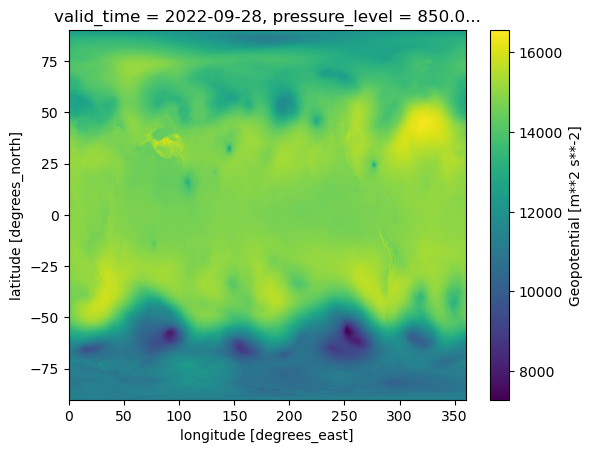

In [5]:
lower_pressure['z'].plot()

In [6]:
upper_pressure = test.isel(valid_time=0, pressure_level=-1)
upper_pressure

<xarray.Dataset>
Dimensions:         (latitude: 721, longitude: 1440)
Coordinates:
    valid_time      datetime64[ns] 2022-09-28
    pressure_level  float64 200.0
  * latitude        (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude       (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    number          int64 ...
    expver          object ...
    z               (latitude, longitude) float32 ...
    t               (latitude, longitude) float32 ...
    u               (latitude, longitude) float32 ...
    v               (latitude, longitude) float32 ...
    w               (latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-19T17:48 GRIB to CDM+CF via cfgrib-0.9.1...

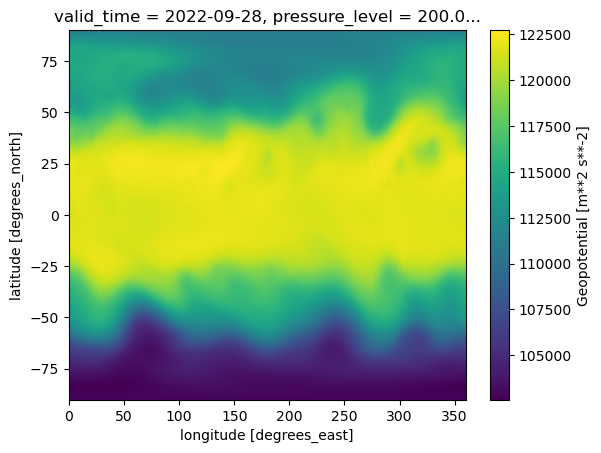

In [7]:
upper_pressure['z'].plot()

In [8]:
upper_pressure.coords

Coordinates:
    valid_time      datetime64[ns] 2022-09-28
    pressure_level  float64 200.0
  * latitude        (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude       (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8

In [9]:
x_dict = {coord: arr.values for coord, arr in upper_pressure.coords.items()}
x_dict

{'valid_time': numpy.datetime64('2022-09-28T00:00:00.000000000'),
 'pressure_level': array(200.),
 'latitude': array([ 90.  ,  89.75,  89.5 ,  89.25,  89.  ,  88.75,  88.5 ,  88.25,
         88.  ,  87.75,  87.5 ,  87.25,  87.  ,  86.75,  86.5 ,  86.25,
         86.  ,  85.75,  85.5 ,  85.25,  85.  ,  84.75,  84.5 ,  84.25,
         84.  ,  83.75,  83.5 ,  83.25,  83.  ,  82.75,  82.5 ,  82.25,
         82.  ,  81.75,  81.5 ,  81.25,  81.  ,  80.75,  80.5 ,  80.25,
         80.  ,  79.75,  79.5 ,  79.25,  79.  ,  78.75,  78.5 ,  78.25,
         78.  ,  77.75,  77.5 ,  77.25,  77.  ,  76.75,  76.5 ,  76.25,
         76.  ,  75.75,  75.5 ,  75.25,  75.  ,  74.75,  74.5 ,  74.25,
         74.  ,  73.75,  73.5 ,  73.25,  73.  ,  72.75,  72.5 ,  72.25,
         72.  ,  71.75,  71.5 ,  71.25,  71.  ,  70.75,  70.5 ,  70.25,
         70.  ,  69.75,  69.5 ,  69.25,  69.  ,  68.75,  68.5 ,  68.25,
         68.  ,  67.75,  67.5 ,  67.25,  67.  ,  66.75,  66.5 ,  66.25,
         66.  ,  65.75,  6

In [10]:
x_dict['valid_time']

numpy.datetime64('2022-09-28T00:00:00.000000000')

In [11]:
solution_vars = ['w', 't', 'z']
solutions = {}

In [12]:
south_boundary_t0 = test.isel(valid_time=0, latitude=-1)
south_boundary_t0

<xarray.Dataset>
Dimensions:         (pressure_level: 17, longitude: 1440)
Coordinates:
    valid_time      datetime64[ns] 2022-09-28
  * pressure_level  (pressure_level) float64 850.0 825.0 800.0 ... 225.0 200.0
    latitude        float64 -90.0
  * longitude       (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    number          int64 ...
    expver          object ...
    z               (pressure_level, longitude) float32 ...
    t               (pressure_level, longitude) float32 ...
    u               (pressure_level, longitude) float32 ...
    v               (pressure_level, longitude) float32 ...
    w               (pressure_level, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-19T17:48 GRIB to CDM+CF via cfgrib-0.9.1...

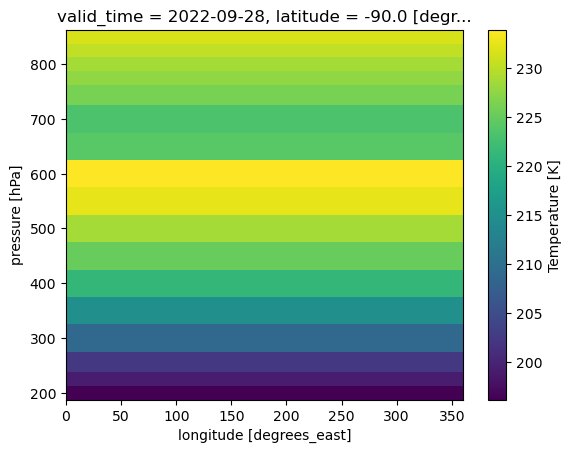

In [13]:
south_boundary_t0['t'].plot()

In [14]:
north_boundary_t0 = test.isel(valid_time=0, latitude=0)
north_boundary_t0

<xarray.Dataset>
Dimensions:         (pressure_level: 17, longitude: 1440)
Coordinates:
    valid_time      datetime64[ns] 2022-09-28
  * pressure_level  (pressure_level) float64 850.0 825.0 800.0 ... 225.0 200.0
    latitude        float64 90.0
  * longitude       (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    number          int64 ...
    expver          object ...
    z               (pressure_level, longitude) float32 ...
    t               (pressure_level, longitude) float32 ...
    u               (pressure_level, longitude) float32 ...
    v               (pressure_level, longitude) float32 ...
    w               (pressure_level, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-19T17:48 GRIB to CDM+CF via cfgrib-0.9.1...

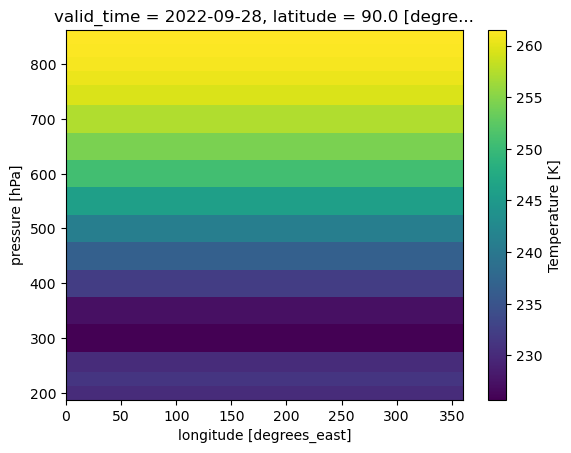

In [15]:
north_boundary_t0['t'].plot()

In [16]:
north_boundary_t0.t.values

array([[261.50452, 261.50452, 261.50452, ..., 261.50452, 261.50452,
        261.50452],
       [261.28714, 261.28714, 261.28714, ..., 261.28714, 261.28714,
        261.28714],
       [261.01126, 261.01126, 261.01126, ..., 261.01126, 261.01126,
        261.01126],
       ...,
       [230.15173, 230.15173, 230.15173, ..., 230.15173, 230.15173,
        230.15173],
       [231.27957, 231.27957, 231.27957, ..., 231.27957, 231.27957,
        231.27957],
       [230.17863, 230.17863, 230.17863, ..., 230.17863, 230.17863,
        230.17863]], dtype=float32)

rows = pressure_level.values
columns = latitude.values

In [17]:
inner = test.isel(valid_time=0, pressure_level=slice(1,-1), latitude=slice(1,-1), longitude=slice(1,-1))
inner

<xarray.Dataset>
Dimensions:         (pressure_level: 15, latitude: 719, longitude: 1438)
Coordinates:
    valid_time      datetime64[ns] 2022-09-28
  * pressure_level  (pressure_level) float64 825.0 800.0 775.0 ... 250.0 225.0
  * latitude        (latitude) float64 89.75 89.5 89.25 ... -89.25 -89.5 -89.75
  * longitude       (longitude) float64 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5
Data variables:
    number          int64 ...
    expver          object ...
    z               (pressure_level, latitude, longitude) float32 ...
    t               (pressure_level, latitude, longitude) float32 ...
    u               (pressure_level, latitude, longitude) float32 ...
    v               (pressure_level, latitude, longitude) float32 ...
    w               (pressure_level, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-19T17:48 GRIB to CDM+CF via cfgrib-0.9.1...

In [18]:
eastern_boundary_t0 = test.isel(valid_time=0, longitude=0)
eastern_boundary_t0

<xarray.Dataset>
Dimensions:         (pressure_level: 17, latitude: 721)
Coordinates:
    valid_time      datetime64[ns] 2022-09-28
  * pressure_level  (pressure_level) float64 850.0 825.0 800.0 ... 225.0 200.0
  * latitude        (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    longitude       float64 0.0
Data variables:
    number          int64 ...
    expver          object ...
    z               (pressure_level, latitude) float32 ...
    t               (pressure_level, latitude) float32 ...
    u               (pressure_level, latitude) float32 ...
    v               (pressure_level, latitude) float32 ...
    w               (pressure_level, latitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-19T17:48 GRIB to CDM+CF via cfgrib-0.9.1...

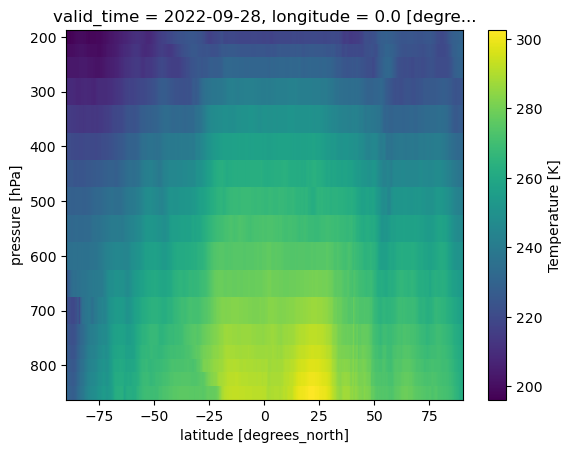

In [19]:
import matplotlib.pyplot as plt

eastern_boundary_t0['t'].plot()
# Get current axes
ax = plt.gca()

# Invert y-axis
ax.invert_yaxis()

plt.show()


In [20]:
western_boundary_t0 = test.isel(valid_time=0, longitude=-721)
western_boundary_t0

<xarray.Dataset>
Dimensions:         (pressure_level: 17, latitude: 721)
Coordinates:
    valid_time      datetime64[ns] 2022-09-28
  * pressure_level  (pressure_level) float64 850.0 825.0 800.0 ... 225.0 200.0
  * latitude        (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    longitude       float64 179.8
Data variables:
    number          int64 ...
    expver          object ...
    z               (pressure_level, latitude) float32 ...
    t               (pressure_level, latitude) float32 ...
    u               (pressure_level, latitude) float32 ...
    v               (pressure_level, latitude) float32 ...
    w               (pressure_level, latitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-19T17:48 GRIB to CDM+CF via cfgrib-0.9.1...

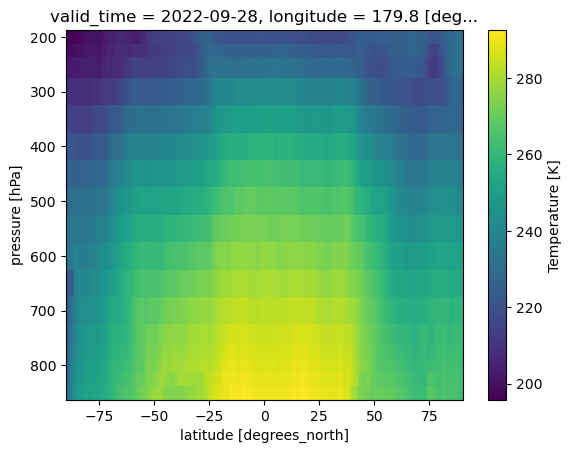

In [21]:


# Plot
western_boundary_t0.t.plot()

# Get current axes
ax = plt.gca()

# Invert y-axis
ax.invert_yaxis()

plt.show()

In [22]:
western_boundary_t0.coords

Coordinates:
    valid_time      datetime64[ns] 2022-09-28
  * pressure_level  (pressure_level) float64 850.0 825.0 800.0 ... 225.0 200.0
  * latitude        (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    longitude       float64 179.8

In [23]:
for i in test.data_vars:
    print(i)

number
expver
z
t
u
v
w


In [24]:
solution_vars = ['w', 't', 'z']
solution_domain = {}
for k in solution_vars:
    v = test[k].values           # this is an xarray.DataArray
    solution_domain[k] = v


solution_domain

{'w': array([[[[ 3.81450653e-02,  3.81450653e-02,  3.81450653e-02, ...,
            3.81450653e-02,  3.81450653e-02,  3.81450653e-02],
          [ 7.69634247e-02,  7.67192841e-02,  7.67192841e-02, ...,
            7.72075653e-02,  7.72075653e-02,  7.69634247e-02],
          [ 7.96489716e-02,  7.96489716e-02,  7.96489716e-02, ...,
            7.98931122e-02,  7.98931122e-02,  7.98931122e-02],
          ...,
          [ 2.88677216e-02,  2.91118622e-02,  2.96001434e-02, ...,
            2.78911591e-02,  2.83794403e-02,  2.86235809e-02],
          [ 4.71782684e-02,  4.74224091e-02,  4.76665497e-02, ...,
            4.66899872e-02,  4.69341278e-02,  4.69341278e-02],
          [ 6.98833466e-02,  6.98833466e-02,  6.98833466e-02, ...,
            6.98833466e-02,  6.98833466e-02,  6.98833466e-02]],
 
         [[ 4.40721512e-02,  4.40721512e-02,  4.40721512e-02, ...,
            4.40721512e-02,  4.40721512e-02,  4.40721512e-02],
          [ 6.77537918e-02,  6.77537918e-02,  6.75096512e-02, ...,


In [25]:

read_data_fn = xr.open_dataset

era5 = ERA5MultiData(root_dir, read_data_fn ,solution_vars=solution_vars)

In [26]:
era5.read_data_fn

<function xarray.backends.api.open_dataset(filename_or_obj: 'str | os.PathLike[Any] | BufferedIOBase | AbstractDataStore', *, engine: 'T_Engine' = None, chunks: 'T_Chunks' = None, cache: 'bool | None' = None, decode_cf: 'bool | None' = None, mask_and_scale: 'bool | None' = None, decode_times: 'bool | None' = None, decode_timedelta: 'bool | None' = None, use_cftime: 'bool | None' = None, concat_characters: 'bool | None' = None, decode_coords: "Literal['coordinates', 'all'] | bool | None" = None, drop_variables: 'str | Iterable[str] | None' = None, inline_array: 'bool' = False, chunked_array_type: 'str | None' = None, from_array_kwargs: 'dict[str, Any] | None' = None, backend_kwargs: 'dict[str, Any] | None' = None, **kwargs) -> 'Dataset'>

In [27]:
era5.root_dir

'C:\\Users\\micke\\Downloads\\dfda178b22d3772b9b9b0118dba68a02.nc'

In [28]:
era5.lower_bounds

{'coords': {'valid_time': numpy.datetime64('2022-09-28T00:00:00.000000000'),
  'pressure_level': 200.0,
  'latitude': -90.0,
  'longitude': 0.0},
 'solution': {'w': -0.8591015382135333, 't': 193.5794, 'z': 6847.9023}}

In [29]:
era5.upper_bounds

{'coords': {'valid_time': numpy.datetime64('2022-09-28T23:00:00.000000000'),
  'pressure_level': 850.0,
  'latitude': 90.0,
  'longitude': 359.75},
 'solution': {'w': 3.460000736750254, 't': 305.72162, 'z': 122770.81}}

In [30]:
era5.solution_mean

{'w': -0.0001722839501004001, 't': 252.08226, 'z': 54354.773}

In [31]:
era5.solution_std

{'w': 0.029370193906786378, 't': 24.21776, 'z': 33400.055}

In [32]:
era5.solution_vars

['w', 't', 'z']

In [33]:
pressure_surface_coords, pressure_surface_solutions = era5.get_pressure_surface()

In [34]:
pressure_surface_coords

{'valid_time': array(['2022-09-28T00:00:00.000000000', '2022-09-28T00:00:00.000000000',
        '2022-09-28T00:00:00.000000000', ...,
        '2022-09-28T00:00:00.000000000', '2022-09-28T00:00:00.000000000',
        '2022-09-28T00:00:00.000000000'], dtype='datetime64[ns]'),
 'pressure_level': array([850., 850., 850., ..., 850., 850., 850.]),
 'latitude': array([ 90.,  90.,  90., ..., -90., -90., -90.]),
 'longitude': array([0.0000e+00, 2.5000e-01, 5.0000e-01, ..., 3.5925e+02, 3.5950e+02,
        3.5975e+02])}

In [35]:
pressure_surface_solutions

{'w': array([-0.00343517, -0.00343517, -0.00343517, ..., -0.00557308,
        -0.00557308, -0.00557308]),
 't': array([261.50452, 261.50452, 261.50452, ..., 231.57481, 231.57481,
        231.57481], dtype=float32),
 'z': array([12225.234, 12225.234, 12225.234, ..., 11282.984, 11282.984,
        11282.984], dtype=float32)}

In [36]:
inner_volume_coords, inner_volume_solutions = era5.get_inner_volume()

In [37]:
inner_volume_coords

{'valid_time': array(['2022-09-28T00:00:00.000000000', '2022-09-28T00:00:00.000000000',
        '2022-09-28T00:00:00.000000000', ...,
        '2022-09-28T23:00:00.000000000', '2022-09-28T23:00:00.000000000',
        '2022-09-28T23:00:00.000000000'], dtype='datetime64[ns]'),
 'pressure_level': array([825., 825., 825., ..., 225., 225., 225.]),
 'latitude': array([ 89.75,  89.75,  89.75, ..., -89.75, -89.75, -89.75]),
 'longitude': array([2.5000e-01, 5.0000e-01, 7.5000e-01, ..., 3.5900e+02, 3.5925e+02,
        3.5950e+02])}

In [38]:
len(inner_volume_coords['valid_time'])

372211920

In [39]:
collocation_points = era5.get_collocation_points(num_samples=10000)

In [40]:
collocation_points

{'valid_time': array([numpy.datetime64('2022-09-28T14:27:37.363754958'),
        numpy.datetime64('2022-09-28T12:22:02.432239767'),
        numpy.datetime64('2022-09-28T13:26:02.073740446'), ...,
        numpy.datetime64('2022-09-28T00:44:38.896970710'),
        numpy.datetime64('2022-09-28T06:40:55.164211782'),
        numpy.datetime64('2022-09-28T09:17:40.726589855')], dtype=object),
 'pressure_level': array([741.8001557401586, 386.63412373042286, 349.6243028743504, ...,
        386.75876464500385, 332.9997781222294, 671.9583398679245],
       dtype=object),
 'latitude': array([16.57434212094938, 44.38006890871176, -74.64189914375594, ...,
        -22.14124912527471, -81.60445781306481, -22.598843084034044],
       dtype=object),
 'longitude': array([319.8066297245953, 268.92258607279376, 7.808898717366611, ...,
        67.22780186097013, 91.50274638467405, 52.363634216935],
       dtype=object)}

In [41]:
coords, solutions = era5.get_full_data()

In [42]:
coords

{'valid_time': array(['2022-09-28T00:00:00.000000000', '2022-09-28T00:00:00.000000000',
        '2022-09-28T00:00:00.000000000', ...,
        '2022-09-28T23:00:00.000000000', '2022-09-28T23:00:00.000000000',
        '2022-09-28T23:00:00.000000000'], dtype='datetime64[ns]'),
 'pressure_level': array([850., 850., 850., ..., 200., 200., 200.]),
 'latitude': array([ 90.,  90.,  90., ..., -90., -90., -90.]),
 'longitude': array([0.0000e+00, 2.5000e-01, 5.0000e-01, ..., 3.5925e+02, 3.5950e+02,
        3.5975e+02])}

In [43]:
solutions

{'w': array([-0.00343517, -0.00343517, -0.00343517, ..., -0.00127368,
        -0.00127368, -0.00127368]),
 't': array([261.50452, 261.50452, 261.50452, ..., 196.9173 , 196.9173 ,
        196.9173 ], dtype=float32),
 'z': array([ 12225.234,  12225.234,  12225.234, ..., 102618.44 , 102618.44 ,
        102618.44 ], dtype=float32)}